In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

import rasterio
from rasterio.fill import fillnodata
from rasterio.windows import from_bounds, Window
from rasterio.transform import rowcol
from rasterio.plot import show
from rasterio.features import shapes

import xarray as xr
import rioxarray
from pysheds.grid import Grid

import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

In [3]:
root = Path(os.getcwd())
data_root = root / "data"

In [173]:
dtm_dir = data_root / "DTM_rlp"
dtm_path = dtm_dir / "DTM Germany_Rheinland-Pfalz 20m.tif"
dtm_crop_path = dtm_dir / "dtm_crop.tif"

print(dtm_path)
print(dtm_crop_path)

c:\Users\Administrator\PythonProjects\abfluss_queich\data\DTM_rlp\DTM Germany_Rheinland-Pfalz 20m.tif
c:\Users\Administrator\PythonProjects\abfluss_queich\data\DTM_rlp\dtm_crop.tif


### Open hyras precip files and crop ROI

In [288]:
# Hyras path
hyras_dir = data_root / "precip_hyras"
hyras_paths = [p for p in hyras_dir.rglob("*.nc")]

# Catchment path
basin_path = dtm_dir / "catchment_queich_siebeldingen.gpkg"
basin = gpd.read_file(basin_path)

In [ ]:
ds = xr.open_dataset(hyras_paths[0])

xarray.core.dataset.Dataset

In [357]:
def read_rio_and_clip(
    ds: xr.core.dataset.Dataset, 
    basin: gpd.GeoDataFrame
    ):
    
    epsg = ds.crs.epsg_code
    precip = ds["pr"]
    
    # Reproject both to same crs
    precip = precip.rio.write_crs(epsg)
    basin = basin.to_crs(epsg)
    
    # Clip precip to basin contour
    precip_clip = precip.rio.clip(
        basin.geometry,
        drop=True
    )
    
    return precip_clip    

In [ ]:
# Read and clip ds
precip_clip = read_rio_and_clip(ds=ds, basin=basin)

# Plot one timestep
precip_clip.isel(time=1).plot()

In [335]:
# Mean per timestep
mean_precip = precip_clip.mean(dim=["y", "x"], skipna=True)

<Axes: xlabel='time'>

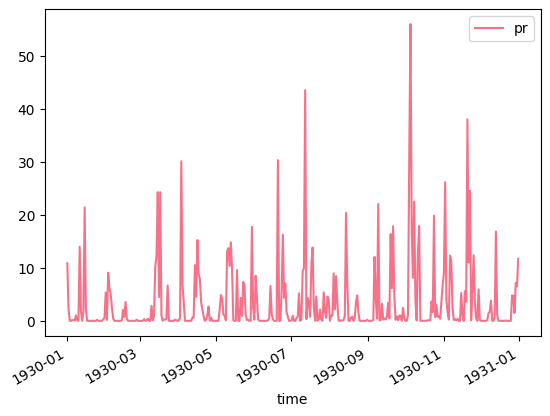

In [348]:
# Convert to dataframe
df_mean_precip = mean_precip.to_dataframe()
df_mean_precip = df_mean_precip[["pr"]]

df_mean_precip.plot()